In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import urllib.request
import xarray as xr
import geopandas as gpd
import rioxarray as rio
from shapely.geometry import mapping, Polygon
import cartopy.crs as ccrs
import calendar
import matplotlib as mpl
import xarray as xr
import time

C:\Users\HP\AppData\Roaming\Python\Python39\site-packages\geopandas\_compat.py:124: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import os
wd = "F:/Masters/ML in Civil and Env/"
os.listdir(wd)

['Chennai_Meenambakkam.csv',
 'CMIP6_ET0_0.5_SD.pdf',
 'CMIP6_ET0_PET_SD.pdf',
 'CMIP6_ET0_SEA.pdf',
 'CMIP6_SD_Senegal.pdf',
 'Commentary.docx',
 'Commentary_ET.docx',
 'Coursework',
 'dataset',
 'Images',
 'Literature',
 'Maaz-Presentation.pptx',
 'Manuscript.docx',
 'Manuscript_SD.docx',
 'ML_models',
 'PET_GCM_Infographic.png',
 'Saudi_ET_paper_2010.pdf',
 'Saudi_Shapefile',
 'Saudi_Shapefile.zip',
 'SD_Paper.pdf',
 'SD_Paper2.pdf',
 'SD_Paper3.pdf',
 'SD_paper_ref.pdf',
 'stacked_dataset.csv',
 '~$mmentary.docx']

In [3]:
ds = xr.open_dataset(wd+"dataset/saudi_final_dataset2.nc")

In [4]:
ds

<xarray.Dataset>
Dimensions:      (time: 420, lon: 231, lat: 191)
Coordinates:
  * time         (time) datetime64[ns] 1980-01-31 1980-02-29 ... 2014-12-31
  * lon          (lon) float64 34.0 34.1 34.2 34.3 34.4 ... 56.7 56.8 56.9 57.0
  * lat          (lat) float64 14.0 14.1 14.2 14.3 14.4 ... 32.7 32.8 32.9 33.0
Data variables:
    spatial_ref  int32 ...
    tasmax       (time, lat, lon) float32 ...
    tasmin       (time, lat, lon) float32 ...
    tas          (time, lat, lon) float32 ...
    rsdt         (time, lat, lon) float32 ...
    sfcWind      (time, lat, lon) float32 ...
    hurs         (time, lat, lon) float32 ...
    pet          (time, lat, lon) float32 ...
    aet          (time, lat, lon) float32 ...

In [5]:
df = ds.to_dataframe().reset_index()

In [6]:
df.head(10)
df.pop('spatial_ref')

0           0
1           0
2           0
3           0
4           0
           ..
18530815    0
18530816    0
18530817    0
18530818    0
18530819    0
Name: spatial_ref, Length: 18530820, dtype: int32

In [7]:
len(df)

18530820

In [8]:
df

,time,lon,lat,tasmax,tasmin,tas,rsdt,sfcWind,hurs,pet,aet
0,1980-01-31,34.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1980-01-31,34.0,14.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1980-01-31,34.0,14.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1980-01-31,34.0,14.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1980-01-31,34.0,14.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
18530815,2014-12-31,57.0,32.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18530816,2014-12-31,57.0,32.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18530817,2014-12-31,57.0,32.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18530818,2014-12-31,57.0,32.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

time              0
lon               0
lat               0
tasmax     11247180
tasmin     11247180
tas        11247180
rsdt       11247180
sfcWind    11247180
hurs       11247180
pet        11247180
aet        11247180
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.to_csv(wd+"stacked_dataset.csv")

In [12]:
def r_squared(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[1][0]
    r2 = r**2
    return r2

def r_coef(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[1][0]
    return r

def rmse(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    return rmse

def mae(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    return mae

def mape(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mape

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    nash = 1 - (ss_res / ss_total)
    return nash

def md(y_true, y_pred):
    md = 1 - (np.sum((y_true - y_pred)**2) / np.sum((np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))**2))
    return md

def kge_metrics(y_true, y_pred):
    kge = 1 - ((((r_coef(y_true, y_pred))-1)**2)+(((np.std(y_true)/np.std(y_pred))-1)**2)+(((np.mean(y_true)/np.mean(y_true))-1)**2))**0.5
    return kge

In [13]:
df.dtypes

time       datetime64[ns]
lon               float64
lat               float64
tasmax            float32
tasmin            float32
tas               float32
rsdt              float32
sfcWind           float32
hurs              float32
pet               float32
aet               float32
dtype: object

In [14]:
df_train = df[(df['time'] < '2010-01-01')]
df_test = df[(df['time'] >= '2010-01-01')]

In [15]:
df_train

,time,lon,lat,tasmax,tasmin,tas,rsdt,sfcWind,hurs,pet,aet
1286,1980-01-31,34.6,28.0,18.001638,8.420901,12.900379,260.005524,3.285503,55.528660,105.573868,4.424326e-13
1287,1980-01-31,34.6,28.1,17.754173,7.946930,12.537847,259.336456,3.214504,55.773056,107.165810,3.484952e-01
1478,1980-01-31,34.7,28.1,17.740145,7.933853,12.527617,259.338379,3.214555,55.519844,124.944679,7.348962e-01
1669,1980-01-31,34.8,28.1,17.721277,7.841335,12.471959,259.340302,3.212249,55.266632,123.727066,4.508343e-01
1670,1980-01-31,34.8,28.2,17.477003,7.349239,12.099354,258.670502,3.142175,55.491879,126.656242,5.136307e-01
...,...,...,...,...,...,...,...,...,...,...,...
15880772,2009-12-31,55.6,21.7,27.721590,13.443828,20.204597,286.296967,2.554354,45.879776,93.203194,0.000000e+00
15880773,2009-12-31,55.6,21.8,27.678139,13.422002,20.174734,285.636993,2.538345,46.162521,93.469658,0.000000e+00
15880774,2009-12-31,55.6,21.9,27.634857,13.400411,20.144693,284.976471,2.526611,46.493919,92.998184,0.000000e+00
15880775,2009-12-31,55.6,22.0,27.590904,13.387199,20.117628,284.315033,2.526122,46.825314,92.119881,0.000000e+00


In [16]:
X = df_train.drop(['time','pet', 'aet'],axis=1)

In [17]:
Y = df_train['pet']

In [18]:
Y2 = df_train['aet']

In [19]:
X_Test = df_test.drop(['time','pet', 'aet'],axis=1)
Y_Test = df_test['pet']
Y2_Test = df_test['aet']

In [20]:
X

,lon,lat,tasmax,tasmin,tas,rsdt,sfcWind,hurs
1286,34.6,28.0,18.001638,8.420901,12.900379,260.005524,3.285503,55.528660
1287,34.6,28.1,17.754173,7.946930,12.537847,259.336456,3.214504,55.773056
1478,34.7,28.1,17.740145,7.933853,12.527617,259.338379,3.214555,55.519844
1669,34.8,28.1,17.721277,7.841335,12.471959,259.340302,3.212249,55.266632
1670,34.8,28.2,17.477003,7.349239,12.099354,258.670502,3.142175,55.491879
...,...,...,...,...,...,...,...,...
15880772,55.6,21.7,27.721590,13.443828,20.204597,286.296967,2.554354,45.879776
15880773,55.6,21.8,27.678139,13.422002,20.174734,285.636993,2.538345,46.162521
15880774,55.6,21.9,27.634857,13.400411,20.144693,284.976471,2.526611,46.493919
15880775,55.6,22.0,27.590904,13.387199,20.117628,284.315033,2.526122,46.825314


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1)

In [23]:
from xgboost import XGBRegressor

xgb_model_pet = XGBRegressor(n_estimators=100, max_depth=5, gamma = 0, booster = 'gbtree')

start_time = time.time()
xgb_model_pet.fit(x_train, y_train)
print("--- %s seconds ---" % (time.time() - start_time))

y_xgb = xgb_model_pet.predict(x_test)
y_xgb_t = xgb_model_pet.predict(x_train)

--- 35.31056499481201 seconds ---


In [24]:
print(f"R-squared (R2): Test {r_squared(y_test, y_xgb)}, Train {r_squared(y_train, y_xgb_t)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(y_test, y_xgb)}, Train {rmse(y_train, y_xgb_t)}")
print(f"Mean Absolute Error (MAE): Test {mae(y_test, y_xgb)}, Train {mae(y_train, y_xgb_t)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(y_test, y_xgb)}, Train {kge_metrics(y_train, y_xgb_t)}")

R-squared (R2): Test 0.8958369264899123, Train 0.8959452951123192
Root Mean Squared Error (RMSE): Test 16.166236373575888, Train 16.119111161255333
Mean Absolute Error (MAE): Test 12.273608207702637, Train 12.24853515625
Kling-Gupta Efficiency (KGE): Test 0.9167696912978112, Train 0.9188904589781


In [25]:
y_xgb_test = xgb_model_pet.predict(X_Test)
print(f"R-squared (R2): Test {r_squared(Y_Test, y_xgb_test)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(Y_Test, y_xgb_test)}")
print(f"Mean Absolute Error (MAE): Test {mae(Y_Test, y_xgb_test)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(Y_Test, y_xgb_test)}")

R-squared (R2): Test 0.8909400727399548
Root Mean Squared Error (RMSE): Test 16.09428378210675
Mean Absolute Error (MAE): Test 12.30611515045166
Kling-Gupta Efficiency (KGE): Test 0.9431555683118306


In [ ]:
xgb_model_pet.feature_importances_

In [102]:
from sklearn.ensemble import RandomForestRegressor

rf_model_pet = RandomForestRegressor(n_estimators= 10, min_samples_split=3, criterion = "squared_error", max_depth = 3)

start_time = time.time()
rf_model_pet.fit(x_train, y_train)
print("--- %s seconds ---" % (time.time() - start_time))

y_rf = rf_model_pet.predict(x_test)
y_rf_t = rf_model_pet.predict(x_train)

--- 166.57547783851624 seconds ---


In [103]:
print(f"R-squared (R2): Test {r_squared(y_test, y_rf)}, Train {r_squared(y_train, y_rf_t)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(y_test, y_rf)}, Train {rmse(y_train, y_rf_t)}")
print(f"Mean Absolute Error (MAE): Test {mae(y_test, y_rf)}, Train {mae(y_train, y_rf_t)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(y_test, y_rf)}, Train {kge_metrics(y_train, y_rf_t)}")

R-squared (R2): Test 0.6912439616403719, Train 0.6910173316477077
Root Mean Squared Error (RMSE): Test 27.83897180149244, Train 27.86205055635831
Mean Absolute Error (MAE): Test 21.132047116832847, Train 21.152504452624264
Kling-Gupta Efficiency (KGE): Test 0.7348661581048831, Train 0.7365686747960956


In [104]:
y_rf_test = rf_model_pet.predict(X_Test)
print(f"R-squared (R2): Test {r_squared(Y_Test, y_rf_test)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(Y_Test, y_rf_test)}")
print(f"Mean Absolute Error (MAE): Test {mae(Y_Test, y_rf_test)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(Y_Test, y_rf_test)}")

R-squared (R2): Test 0.694577192043248
Root Mean Squared Error (RMSE): Test 26.76336342212171
Mean Absolute Error (MAE): Test 20.485729831120963
Kling-Gupta Efficiency (KGE): Test 0.7594476299872571


In [ ]:
rf_model_pet.feature_importances_

###### AET

In [114]:
x_train, x_test, y_train, y_test = train_test_split(X, Y2, test_size = 0.2, random_state = 1)

In [115]:
from xgboost import XGBRegressor

xgb_model_aet = XGBRegressor(n_estimators=100, max_depth=5, gamma = 0, booster = 'gbtree')

start_time = time.time()
xgb_model_aet.fit(x_train, y_train)
print("--- %s seconds ---" % (time.time() - start_time))

y_xgb = xgb_model_aet.predict(x_test)
y_xgb_t = xgb_model_aet.predict(x_train)

--- 29.568567037582397 seconds ---


In [116]:
print(f"R-squared (R2): Test {r_squared(y_test, y_xgb)}, Train {r_squared(y_train, y_xgb_t)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(y_test, y_xgb)}, Train {rmse(y_train, y_xgb_t)}")
print(f"Mean Absolute Error (MAE): Test {mae(y_test, y_xgb)}, Train {mae(y_train, y_xgb_t)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(y_test, y_xgb)}, Train {kge_metrics(y_train, y_xgb_t)}")

R-squared (R2): Test 0.47515482394396585, Train 0.4795882095326143
Root Mean Squared Error (RMSE): Test 4.126197872208171, Train 4.115365307376634
Mean Absolute Error (MAE): Test 2.4239304065704346, Train 2.407104730606079
Kling-Gupta Efficiency (KGE): Test 0.39041911363210524, Train 0.4129255466102504


In [117]:
y_xgb_test = xgb_model_aet.predict(X_Test)
print(f"R-squared (R2): Test {r_squared(Y2_Test, y_xgb_test)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(Y2_Test, y_xgb_test)}")
print(f"Mean Absolute Error (MAE): Test {mae(Y2_Test, y_xgb_test)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(Y2_Test, y_xgb_test)}")

R-squared (R2): Test 0.40769136787683496
Root Mean Squared Error (RMSE): Test 3.5447347628390187
Mean Absolute Error (MAE): Test 2.236194133758545
Kling-Gupta Efficiency (KGE): Test 0.6310640459651282


In [174]:
rf_model_aet.feature_importances_

array([0.20075244, 0.06548242, 0.46430747, 0.        , 0.        ,
       0.14547807, 0.        , 0.12397959])

In [119]:
from sklearn.ensemble import RandomForestRegressor

rf_model_aet = RandomForestRegressor(n_estimators= 10, min_samples_split=3, criterion = "squared_error", max_depth = 3)

start_time = time.time()
rf_model_aet.fit(x_train, y_train)
print("--- %s seconds ---" % (time.time() - start_time))

y_rf = rf_model_aet.predict(x_test)
y_rf_t = rf_model_aet.predict(x_train)

--- 168.29751253128052 seconds ---


In [120]:
print(f"R-squared (R2): Test {r_squared(y_test, y_rf)}, Train {r_squared(y_train, y_rf_t)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(y_test, y_rf)}, Train {rmse(y_train, y_rf_t)}")
print(f"Mean Absolute Error (MAE): Test {mae(y_test, y_rf)}, Test {mae(y_train, y_rf_t)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(y_test, y_rf)}, Test {kge_metrics(y_train, y_rf_t)}")

R-squared (R2): Test 0.16838444803144068, Train 0.16947392309480222
Root Mean Squared Error (RMSE): Test 5.193880067073662, Train 5.213536625059608
Mean Absolute Error (MAE): Test 3.157012361660115, Test 3.1620142001929343
Kling-Gupta Efficiency (KGE): Test -0.5784020451134715, Test -0.5463236241101523


In [121]:
y_rf_test = rf_model_aet.predict(X_Test)
print(f"R-squared (R2): Test {r_squared(Y2_Test, y_rf_test)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(Y2_Test, y_rf_test)}")
print(f"Mean Absolute Error (MAE): Test {mae(Y2_Test, y_rf_test)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(Y2_Test, y_rf_test)}")

R-squared (R2): Test 0.08765149478397356
Root Mean Squared Error (RMSE): Test 4.229024099183349
Mean Absolute Error (MAE): Test 2.7795744019690716
Kling-Gupta Efficiency (KGE): Test 0.03264698599685201


In [122]:
rf_model_aet.feature_importances_

array([0.20075244, 0.06548242, 0.46430747, 0.        , 0.        ,
       0.14547807, 0.        , 0.12397959])

###### Saving the output XGB files to .nc for further comparison

In [ ]:
###### dfx_train, dfx_test, dfy_train, dfy_test = train_test_split(df_train, Y, test_size = 0.2, random_state = 1)

In [111]:
dfx_train.insert(column = "XGB-PET", value = y_xgb_t, loc = len(dfx_train.columns))
dfx_test.insert(column = "XGB-PET", value = y_xgb, loc = len(dfx_test.columns))
dfx_train.insert(column = "RF-PET", value = y_rf_t, loc = len(dfx_train.columns))
dfx_test.insert(column = "RF-PET", value = y_rf, loc = len(dfx_test.columns))
df_test.insert(column = "XGB-PET", value = y_xgb_test, loc = len(df_test.columns))
df_test.insert(column = "RF-PET", value = y_rf_test, loc = len(df_test.columns))

In [123]:
dfx_train.insert(column = "XGB-AET", value = y_xgb_t, loc = len(dfx_train.columns))
dfx_test.insert(column = "XGB-AET", value = y_xgb, loc = len(dfx_test.columns))
dfx_train.insert(column = "RF-AET", value = y_rf_t, loc = len(dfx_train.columns))
dfx_test.insert(column = "RF-AET", value = y_rf, loc = len(dfx_test.columns))
df_test.insert(column = "XGB-AET", value = y_xgb_test, loc = len(df_test.columns))
df_test.insert(column = "RF-AET", value = y_rf_test, loc = len(df_test.columns))

In [132]:
df_sorted1 = dfx_train.sort_index()
df_sorted2 = dfx_test.sort_index()
df_sorted3 = df_test.sort_index()

In [139]:
DF_calibrate = df_sorted1[['time', 'lat', 'lon','XGB-PET', 'XGB-AET', 'RF-PET', 'RF-AET']]
DF_Validate = df_sorted2[['time', 'lat', 'lon','XGB-PET', 'XGB-AET', 'RF-PET', 'RF-AET']]
DF_Test = df_sorted3[['time', 'lat', 'lon','XGB-PET', 'XGB-AET', 'RF-PET', 'RF-AET']]

In [141]:
DF_calibrate = DF_calibrate.set_index(['time','lat','lon'])
DF_Validate = DF_Validate.set_index(['time','lat','lon'])
DF_Test = DF_Test.set_index(['time','lat','lon'])

In [143]:
ds_cal = xr.Dataset.from_dataframe(DF_calibrate)
ds_val = xr.Dataset.from_dataframe(DF_Validate)
ds_tst = xr.Dataset.from_dataframe(DF_Test)

In [148]:
df_total = pd.concat([df_sorted1, df_sorted2, df_sorted3], axis=0)

In [150]:
df_total = df_total.sort_index()

In [229]:
DF_FULL = df_total[['time', 'lat', 'lon','XGB-PET', 'XGB-AET', 'RF-PET', 'RF-AET']]
DF_XGB = df_total[['time', 'lat', 'lon','XGB-PET', 'XGB-AET']]
DF_RF = df_total[['time', 'lat', 'lon', 'RF-PET', 'RF-AET']]

In [230]:
DF_XGB = DF_XGB.rename(columns={'XGB-PET': 'ETp', 'XGB-AET': 'ETa'})
DF_RF = DF_RF.rename(columns={'RF-PET': 'ETp', 'RF-AET': 'ETa'})

In [231]:
DF_FULL = DF_FULL.set_index(['time','lat','lon'])
DF_XGB = DF_XGB.set_index(['time','lat','lon'])
DF_RF = DF_RF.set_index(['time','lat','lon'])

In [232]:
ds_FULL = xr.Dataset.from_dataframe(DF_FULL)
ds_XGB = xr.Dataset.from_dataframe(DF_XGB)
ds_RF = xr.Dataset.from_dataframe(DF_RF)

In [235]:
ds_cal.to_netcdf(wd+'dataset/ds_calibrate.nc')
ds_val.to_netcdf(wd+'dataset/ds_validate.nc')
ds_tst.to_netcdf(wd+'dataset/ds_test.nc')
ds_FULL.to_netcdf(wd+'dataset/ds_output.nc')
ds_XGB.to_netcdf(wd+'dataset/ds_xgb.nc')
ds_RF.to_netcdf(wd+'dataset/ds_rf.nc')

###### Saving Feature Importance

In [183]:
xgb_model_pet_lst = list(xgb_model_pet.feature_importances_)
xgb_model_aet_lst = list(xgb_model_aet.feature_importances_)
rf_model_pet_lst = list(rf_model_pet.feature_importances_)
rf_model_aet_lst = list(rf_model_aet.feature_importances_)

In [185]:
feature_list = list(x_train.columns)

In [186]:
FI = pd.DataFrame()
FI.insert(column = "Feature", value =feature_list, loc = 0)
FI.insert(column = "XGB-PET", value =xgb_model_pet_lst, loc = 1)
FI.insert(column = "XGB-AET", value =xgb_model_aet_lst, loc = 2)
FI.insert(column = "RF-PET", value =rf_model_pet_lst, loc = 3)
FI.insert(column = "RF-AET", value =rf_model_aet_lst, loc = 4)
FI.to_excel(wd+"dataset/feature_importance.xlsx")

In [176]:
xgb_model_pet.save_model(wd+'ML_models/xgb_pet_model.json')
xgb_model_aet.save_model(wd+'ML_models/xgb_aet_model.json')

###### No need to save RF as it did not perform that well

In [ ]:
rf_model_pet.save_model(wd+'ML_models/rf_pet_model.json')
rf_model_aet.save_model(wd+'ML_models/rf_aet_model.json')

In [213]:
ds_XGB

<xarray.Dataset>
Dimensions:  (time: 420, lat: 158, lon: 211)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-31 1980-02-29 ... 2014-12-31
  * lat      (lat) float64 16.4 16.5 16.6 16.7 16.8 ... 31.7 31.8 31.9 32.0 32.1
  * lon      (lon) float64 34.6 34.7 34.8 34.9 35.0 ... 55.2 55.3 55.4 55.5 55.6
Data variables:
    ETₚ      (time, lat, lon) float32 nan nan nan nan nan ... nan nan nan nan
    ETp      (time, lat, lon) float32 nan nan nan nan nan ... nan nan nan nan

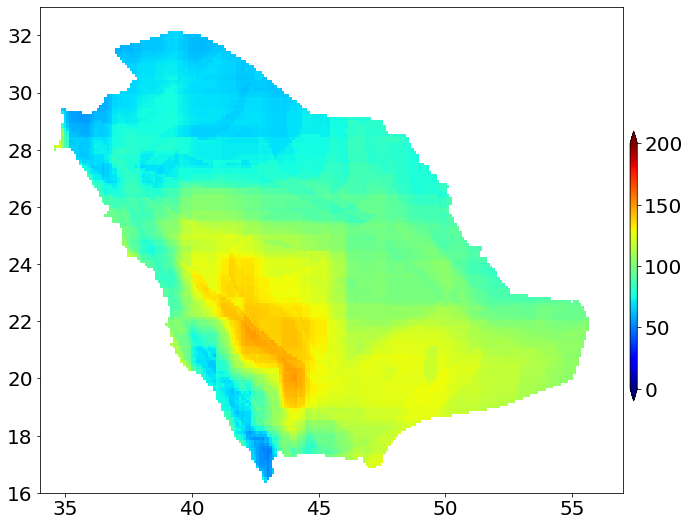

In [225]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (10,7.5))
fig.set_facecolor("white")
plt.subplots_adjust(bottom=0.08, top=0.98, left=0.09, right=0.90, hspace=0.15, wspace = 0.04)

v_min = 0
v_max = 200
c_map = "jet"
var = ds_XGB['ETp']
factor = 1

axes.pcolormesh(var.lon, var.lat, (var[1,:, :])*factor,vmin=v_min, vmax=v_max, cmap = c_map)
axes.set_ylim((16,33))
axes.set_xlim((34,57))
axes.tick_params(axis='both', which='major', labelsize=20)

norm = mpl.colors.Normalize(vmin=v_min, vmax=v_max)
cax = fig.add_axes([0.91, 0.25, 0.010, 0.50])
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = c_map),cax=cax, orientation='vertical', extend = 'both')
cb.ax.tick_params(labelsize=20)

#plt.savefig(wd+'images/monthly_tasmax.png', format = 'png', dpi = 500)

In [227]:
df

,time,lon,lat,tasmax,tasmin,tas,rsdt,sfcWind,hurs,pet,aet
1286,1980-01-31,34.6,28.0,18.001638,8.420901,12.900379,260.005524,3.285503,55.528660,105.573868,4.424326e-13
1287,1980-01-31,34.6,28.1,17.754173,7.946930,12.537847,259.336456,3.214504,55.773056,107.165810,3.484952e-01
1478,1980-01-31,34.7,28.1,17.740145,7.933853,12.527617,259.338379,3.214555,55.519844,124.944679,7.348962e-01
1669,1980-01-31,34.8,28.1,17.721277,7.841335,12.471959,259.340302,3.212249,55.266632,123.727066,4.508343e-01
1670,1980-01-31,34.8,28.2,17.477003,7.349239,12.099354,258.670502,3.142175,55.491879,126.656242,5.136307e-01
...,...,...,...,...,...,...,...,...,...,...,...
18528032,2014-12-31,55.6,21.7,28.619143,14.613130,21.157557,286.464081,2.594476,46.515495,83.708321,0.000000e+00
18528033,2014-12-31,55.6,21.8,28.569921,14.606999,21.138582,285.803925,2.575593,46.737350,83.596573,0.000000e+00
18528034,2014-12-31,55.6,21.9,28.518263,14.604412,21.119665,285.143127,2.561476,47.011810,83.676552,0.000000e+00
18528035,2014-12-31,55.6,22.0,28.465080,14.620155,21.107256,284.481476,2.559897,47.286278,83.371857,0.000000e+00


In [228]:
df = df.set_index(['time','lat','lon'])
ds_masked = xr.Dataset.from_dataframe(df)
ds_masked.to_netcdf(wd+'dataset/ds_masked.nc')

In [ ]:
fig, axes = plt.subplots(nrows = 2,ncols = 4, figsize = (12,5))
fig.set_facecolor("white")
plt.subplots_adjust(bottom=0.10, top=0.95, left=0.08, right=0.90, hspace=0.15, wspace = 0.04)

v_min = 0
v_max = 1
c_map = "jet"
factor = 1

axes[0,0].pcolormesh(ds_org.lon, ds_org.lat, (r_squared_spatial(ds_org['pet'], ds_xgb['ETp'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,0].set_title("XGB-ETp R$^{2}$", fontsize = 12)
axes[0,0].set_xticks([])
axes[0,0].set_ylim((16,33))
axes[0,0].set_xlim((34,57))
bound.boundary.plot(ax=axes[0,0],color='black')

axes[0,1].pcolormesh(ds_org.lon, ds_org.lat, (kge_spatial(ds_org['pet'], ds_xgb['ETp'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,1].set_title("XGB-ETp KGE", fontsize = 12)
axes[0,1].set_xticks([])
axes[0,1].set_yticks([])
axes[0,1].set_ylim((16,33))
axes[0,1].set_xlim((34,57))
bound.boundary.plot(ax=axes[0,1],color='black')


axes[0,2].pcolormesh(ds_org.lon, ds_org.lat, (r_squared_spatial(ds_org['pet'], ds_rf['ETp'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,2].set_title("RF-ETp R$^{2}$", fontsize = 12)
axes[0,2].set_xticks([])
axes[0,2].set_yticks([])
axes[0,2].set_ylim((16,33))
axes[0,2].set_xlim((34,57))
bound.boundary.plot(ax=axes[0,2],color='black')

axes[0,3].pcolormesh(ds_org.lon, ds_org.lat, (kge_spatial(ds_org['pet'], ds_rf['ETp'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,3].set_title("RF-ETp KGE", fontsize = 12)
axes[0,3].set_xticks([])
axes[0,3].set_yticks([])
axes[0,3].set_ylim((16,33))
axes[0,3].set_xlim((34,57))
bound.boundary.plot(ax=axes[0,3],color='black')
    
axes[1,0].pcolormesh(ds_org.lon, ds_org.lat, (r_squared_spatial(ds_org['aet'], ds_xgb['ETa'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,0].set_title("XGB-ETa R$^{2}$", fontsize = 12)
axes[1,0].set_ylim((16,33))
axes[1,0].set_xlim((34,57))
bound.boundary.plot(ax=axes[1,0],color='black')

axes[1,1].pcolormesh(ds_org.lon, ds_org.lat, (kge_spatial(ds_org['aet'], ds_xgb['ETa'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,1].set_title("XGB-ETa KGE", fontsize = 12)
axes[1,1].set_yticks([])
axes[1,1].set_ylim((16,33))
axes[1,1].set_xlim((34,57))
bound.boundary.plot(ax=axes[1,1],color='black')
 
axes[1,2].pcolormesh(ds_org.lon, ds_org.lat, (r_squared_spatial(ds_org['aet'], ds_rf['ETa'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,2].set_title("RF-ETa R$^{2}$", fontsize = 12)
axes[1,2].set_yticks([])
axes[1,2].set_ylim((16,33))
axes[1,2].set_xlim((34,57))
bound.boundary.plot(ax=axes[1,2],color='black')

axes[1,3].pcolormesh(ds_org.lon, ds_org.lat, (kge_spatial(ds_org['aet'], ds_rf['ETa'])),vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,3].set_title("RF-ETa KGE", fontsize = 12)
axes[1,3].set_yticks([])
axes[1,3].set_ylim((16,33))
axes[1,3].set_xlim((34,57))
bound.boundary.plot(ax=axes[1,3],color='black')

norm = mpl.colors.Normalize(vmin=v_min, vmax=v_max)
cax = fig.add_axes([0.91, 0.25, 0.010, 0.50])
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = c_map),cax=cax, orientation='vertical', extend = 'both')
cb.ax.tick_params(labelsize=12)
cb.set_label(label="", color = 'k', size=12)

plt.savefig(wd+'Images/R2_KGE_ETp.png', format = 'png', dpi = 500)